In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
#import geopandas as gpd
#import libpysal

In [ ]:
# 1. โหลดข้อมูล
import csv

df_final = pd.read_csv("/Users/chanokchonkarinrak/Documents/GitHub/AMR_Thesis/MDR/spatiotemperal/acinetobacter_baumannii/a_baumannii_all_regions.csv")

# ตัวแปรตาม (Beta 0-1)
df_final['y_beta'] = df_final['percentage'] / 100.0
# กันค่า 0 และ 1 เป๊ะๆ
df_final['y_beta'] = df_final['y_beta'].clip(lower=0.0001, upper=0.9999) 

# ---------------------------------------------------------
# แบบที่ 1: ฤดูกาลแบบคลื่นต่อเนื่อง (Sine/Cosine)
# ---------------------------------------------------------
df_final['month_numeric'] = df_final['month'].astype(float)
df_final['sin_month'] = np.sin(2 * np.pi * df_final['month_numeric'] / 12)
df_final['cos_month'] = np.cos(2 * np.pi * df_final['month_numeric'] / 12)

# ---------------------------------------------------------
# แบบที่ 2: ฤดูกาลแบบขั้นบันได (3 ฤดูแบบไทย)
# ---------------------------------------------------------
def get_season(m):
    if m in [3, 4, 5]: 
        return 'summer'
    elif m in [6, 7, 8, 9]: 
        return 'rainy'
    else: 
        return 'winter' # 10, 11, 12, 1, 2

df_final['season'] = df_final['month'].apply(get_season)

# แปลงเป็นรหัส (1=ร้อน, 2=ฝน, 3=หนาว)
season_map = {'summer': 1, 'rainy': 2, 'winter': 3}
df_final['season_id'] = df_final['season'].map(season_map)

# ID เชิงพื้นที่ (1-13)
df_final['region_id'] = df_final['region'].astype(int)

# ID เชิงเวลา (เรียงลำดับจากเดือนแรก=1 ไปจนถึงเดือนล่าสุด)
df_final['year_month'] = df_final['year'].astype(str) + df_final['month'].astype(str).str.zfill(2)
unique_time = sorted(df_final['year_month'].unique())
time_map = {tm: i+1 for i, tm in enumerate(unique_time)}
df_final['time_id'] = df_final['year_month'].map(time_map)

# ID สำหรับกลุ่มยา
unique_mdr = sorted(df_final['Resistant_Drug_Classes'].unique())
mdr_map = {mdr: i+1 for i, mdr in enumerate(unique_mdr)}
df_final['mdr_id_numeric'] = df_final['Resistant_Drug_Classes'].map(mdr_map)

print("เตรียม DataFrame (df_final) เสร็จสมบูรณ์! จำนวนแถว:", len(df_final))

#บันทึก DataFrame ที่เตรียมไว้แล้ว
df_final.to_csv("aba_all_region_spatiotemporal_prepared.csv", index=False)

เตรียม DataFrame (df_final) เสร็จสมบูรณ์! จำนวนแถว: 6445


In [ ]:
# ==========================================
# ส่วนที่ 3: สร้างไฟล์แผนที่ map.graph (ไม่ต้องใช้ libpysal)
# ==========================================
import geopandas as gpd

# โหลดไฟล์ JSON แผนที่
gdf = gpd.read_file("Regions_no_province_boundaries.json")

# สำคัญมาก: ต้องเรียงลำดับเขต 1-13 ให้ตรงกับ region_id ในตาราง
gdf = gdf.sort_values('HealthRegion').reset_index(drop=True)

# เขียนไฟล์ map.graph ตามฟอร์แมตที่ R-INLA ต้องการ
with open("map.graph", "w") as f:
    f.write(f"{len(gdf)}\n") # บรรทัดแรกคือจำนวนเขตทั้งหมด (13)
    
    # วนลูปหาเพื่อนบ้านของแต่ละเขต
    for i, row in gdf.iterrows():
        node = i + 1 # INLA เริ่มนับที่ 1
        
        # หาเขตที่ขอบชนกัน (intersects) และต้องไม่ใช่เขตตัวเอง (index != i)
        is_neighbor = gdf.geometry.intersects(row.geometry) & (gdf.index != i)
        
        # ดึง index ของเพื่อนบ้านมาบวก 1 เพื่อให้ตรงกับ INLA (ที่เริ่มนับจาก 1)
        neighbors_idx = gdf[is_neighbor].index.tolist()
        neighbors = [str(n + 1) for n in neighbors_idx]
        
        # เขียนลงไฟล์: "ID_เขต จำนวนเพื่อนบ้าน เพื่อนบ้าน_1 เพื่อนบ้าน_2 ..."
        f.write(f"{node} {len(neighbors)} {' '.join(neighbors)}\n")
        
print("สร้างไฟล์ map.graph ด้วย Geopandas สำเร็จ พร้อมนำไปใช้ใน INLA แล้ว!")

In [4]:
# 1. โหลดข้อมูลผลการทำนาย
print("⏳ กำลังโหลดข้อมูลประเมินผล...")
df = pd.read_csv("Forecast_5Years_All_Patterns_LogitGaussian.csv")

# 2. เลือกเฉพาะข้อมูล "อดีต" (ที่เรามีค่า Actual ให้เปรียบเทียบ)
# สังเกตจากบรรทัดที่ future_year เป็น NaN
df_eval = df[df['future_year'].isna()].copy()

# ลบแถวที่มีค่าว่าง (ป้องกัน Error)
df_eval = df_eval.dropna(subset=['pattern_count', 'total_rows_in_region_month', 'predicted_percent'])

# 3. เริ่มคำนวณตัวแปรสำหรับ WAPE
# ก) แปลงค่า % ทำนาย ให้กลับมาเป็น "จำนวนเคสที่ทำนายได้ (Predicted Cases)"
df_eval['predicted_cases'] = (df_eval['predicted_percent'] / 100) * df_eval['total_rows_in_region_month']

# ข) หาระยะห่าง (Error) ระหว่าง เคสจริง vs เคสที่ทำนาย
df_eval['abs_error'] = np.abs(df_eval['pattern_count'] - df_eval['predicted_cases'])

# 4. คำนวณ WAPE แยกตาม Pattern
print("\n📊 === ผลการประเมินประสิทธิภาพโมเดล INLA ด้วย WAPE ===")
print("เกณฑ์ที่ยอมรับได้: WAPE ควร < 15%\n")

wape_results = []
patterns = sorted(df_eval['mdr_id_numeric'].unique())

for p_id in patterns:
    subset = df_eval[df_eval['mdr_id_numeric'] == p_id]
    
    sum_abs_error = subset['abs_error'].sum()
    sum_actual = subset['pattern_count'].sum()
    
    # สูตร WAPE = (Sum of Absolute Error / Sum of Actual Count) * 100
    if sum_actual > 0:
        wape = (sum_abs_error / sum_actual) * 100
    else:
        wape = np.nan
        
    wape_results.append({
        'Pattern ID': int(p_id),
        'WAPE (%)': round(wape, 2),
        'Status': '✅ ผ่านเกณฑ์ (<15%)' if wape <= 15 else '⚠️ เกินเกณฑ์'
    })

# แสดงผลแบบตาราง
wape_df = pd.DataFrame(wape_results)
print(wape_df.to_string(index=False))

# 5. คำนวณ WAPE ภาพรวมระดับประเทศ (Overall)
overall_error = df_eval['abs_error'].sum()
overall_actual = df_eval['pattern_count'].sum()
overall_wape = (overall_error / overall_actual) * 100

print("-" * 45)
status_overall = "✅ ผ่านเกณฑ์ยอดเยี่ยม" if overall_wape <= 15 else "⚠️ ต้องระวัง (เกิน 15%)"
print(f"🌟 ภาพรวมประเทศ (Overall WAPE) : {overall_wape:.2f}% [{status_overall}]")

⏳ กำลังโหลดข้อมูลประเมินผล...

📊 === ผลการประเมินประสิทธิภาพโมเดล INLA ด้วย WAPE ===
เกณฑ์ที่ยอมรับได้: WAPE ควร < 15%

 Pattern ID  WAPE (%)             Status
          1     10.09 ✅ ผ่านเกณฑ์ (<15%)
          2     34.79       ⚠️ เกินเกณฑ์
          3     41.56       ⚠️ เกินเกณฑ์
          4     39.84       ⚠️ เกินเกณฑ์
          5     47.63       ⚠️ เกินเกณฑ์
---------------------------------------------
🌟 ภาพรวมประเทศ (Overall WAPE) : 17.96% [⚠️ ต้องระวัง (เกิน 15%)]


⏳ กำลังโหลดข้อมูลพยากรณ์...
⏳ กำลังโหลดข้อมูลแผนที่ GeoJSON...


/var/folders/f0/09md1vw56wn4jjhchxblsy0r0000gn/T/ipykernel_1428/152780865.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # เว้นที่ให้แถบสี


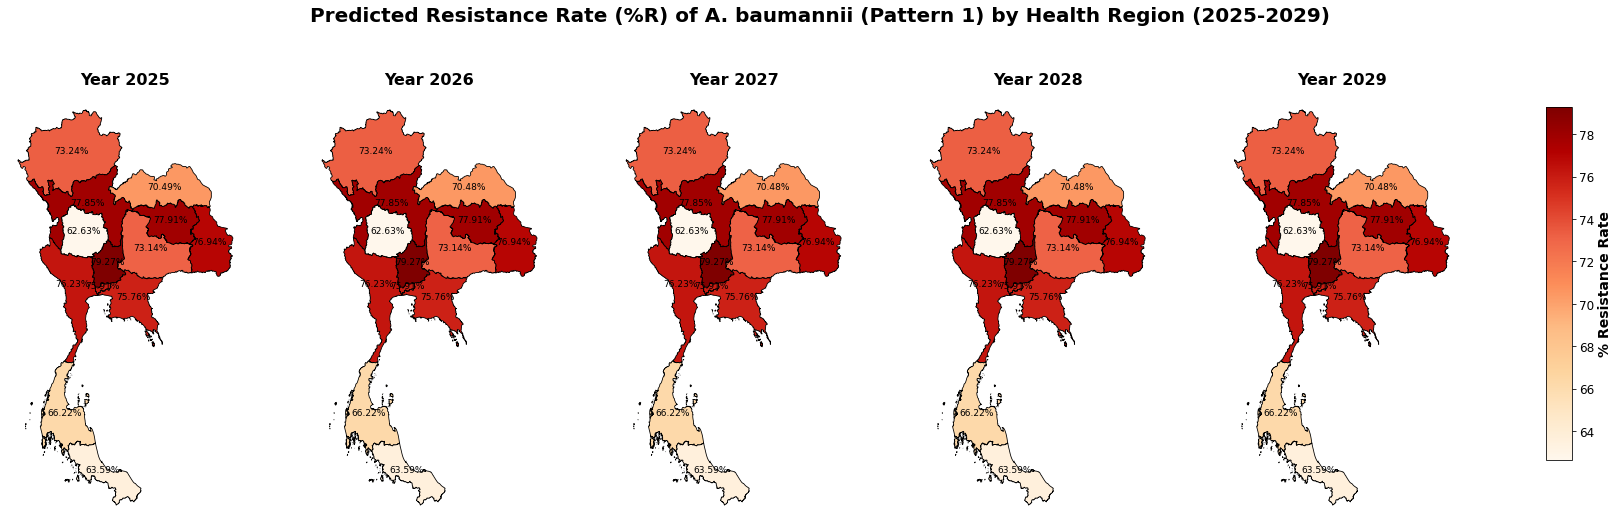


✅ วาดแผนที่เสร็จสมบูรณ์! บันทึกภาพ 'Map_Pattern1_2025_2029.png' เรียบร้อยครับ


In [12]:
# ==========================================
# 1. โหลดข้อมูลผลทำนาย
# ==========================================
print("⏳ กำลังโหลดข้อมูลพยากรณ์...")
df = pd.read_csv("Forecast_5Years_All_Patterns_LogitGaussian.csv")

# กรองเฉพาะ Pattern 1 (mdr_id_numeric == 1) และเป็นข้อมูลทำนาย (forecast)
df_p1 = df[(df['mdr_id_numeric'] == 1) & (df['data_type'] == 'forecast')].copy()

# ยุบข้อมูลรายเดือนให้เป็นค่าเฉลี่ยรายปี ของแต่ละเขตสุขภาพ
df_yearly = df_p1.groupby(['region_id', 'year'])['predicted_percent'].mean().reset_index()

# แปลงตาราง (Pivot) ให้แถวเป็นเขตสุขภาพ และคอลัมน์เป็นปี (2025, 2026, ...)
df_pivot = df_yearly.pivot(index='region_id', columns='year', values='predicted_percent').reset_index()

# ==========================================
# 2. โหลดข้อมูลแผนที่ (GeoJSON / Shapefile)
# ==========================================
print("⏳ กำลังโหลดข้อมูลแผนที่ GeoJSON...")
# ใส่ชื่อไฟล์แผนที่ของคุณแปม
gdf = gpd.read_file('Regions_no_province_boundaries.json')

# ⚠️ สำคัญ: ตรวจสอบชื่อคอลัมน์ใน gdf ที่บอกเลขเขตสุขภาพ (เช่น 'HealthRegion', 'region', 'zone')
# สมมติว่าในไฟล์ชื่อ 'HealthRegion' เราจะเปลี่ยนชื่อให้ตรงกับ df_pivot เพื่อ Merge
geo_col_name = 'HealthRegion'  # <-- เปลี่ยนตรงนี้ให้ตรงกับคอลัมน์จริงในไฟล์ GeoJSON ของคุณแปม
gdf = gdf.rename(columns={geo_col_name: 'region_id'})

# ทำให้แน่ใจว่า type เป็นตัวเลขเหมือนกันก่อน Merge
gdf['region_id'] = gdf['region_id'].astype(int)
df_pivot['region_id'] = df_pivot['region_id'].astype(int)

# นำข้อมูลเปอร์เซ็นต์ดื้อยา ไปรวมเข้ากับแผนที่
gdf_merged = gdf.merge(df_pivot, on='region_id', how='left')

# ==========================================
# 3. เริ่มพล็อตแผนที่ 5 ปี (2025-2029)
# ==========================================
years_to_plot = [2025, 2026, 2027, 2028, 2029]

# หาค่า Min / Max ของเปอร์เซ็นต์ดื้อยาเพื่อล็อคแถบสีให้เท่ากันทุกรูป
vmin = df_yearly['predicted_percent'].min()
vmax = df_yearly['predicted_percent'].max()

# สร้างพื้นที่วาดกราฟแบบ 1 แถว 5 คอลัมน์
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
fig.suptitle('Predicted Resistance Rate (%R) of A. baumannii (Pattern 1) by Health Region (2025-2029)', 
             fontsize=20, fontweight='bold', y=1.05)

# วนลูปวาดแผนที่ทีละปี
for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    # วาดแผนที่
    gdf_merged.plot(column=year, 
                    cmap='OrRd',        # ใช้โทนสี ส้ม-แดง (Orange-Red)
                    linewidth=0.8, 
                    ax=ax, 
                    edgecolor='black',  # เส้นขอบสีดำ
                    vmin=vmin, vmax=vmax, # ล็อคช่วงสี
                    legend=False)       # ปิด legend ย่อยไปก่อน
    
    # ตั้งชื่อแต่ละรูป
    ax.set_title(f'Year {year}', fontsize=16, fontweight='bold')
    ax.axis('off') # ซ่อนเส้นแกน X, Y
    
    # (Optional) ใส่ตัวเลขกำกับตรงกลางแต่ละเขต (ถ้าแผนที่มี Geometry สมบูรณ์)
    for idx, row in gdf_merged.iterrows():
        if pd.notna(row[year]):
            ax.annotate(text=f"{row[year]:.2f}%", 
                        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                        horizontalalignment='center', fontsize=9)

# สร้างแถบสีรวม (Colorbar) ไว้ด้านขวาของรูป
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='OrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = [] # Array เปล่าสำหรับ ScalarMappable
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('% Resistance Rate', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # เว้นที่ให้แถบสี
plt.show()

# บันทึกรูปภาพความละเอียดสูงสำหรับใส่ในเล่ม
fig.savefig('Map_Pattern1_2025_2029.png', dpi=300, bbox_inches='tight')
print("\n✅ วาดแผนที่เสร็จสมบูรณ์! บันทึกภาพ 'Map_Pattern1_2025_2029.png' เรียบร้อยครับ")

In [16]:
# ==========================================
# 1. โหลดและเตรียมข้อมูล
# ==========================================
print("⏳ กำลังเตรียมข้อมูลพยากรณ์รายเดือน (Pattern 1)...")
df = pd.read_csv("Forecast_5Years_All_Patterns_LogitGaussian.csv")

# กรองเอาเฉพาะ Pattern 1 และข้อมูลอนาคต (60 เดือน)
df_p1 = df[(df['mdr_id_numeric'] == 1) & (df['data_type'] == 'forecast')].copy()

# สร้างคอลัมน์ Date สำหรับใช้พล็อตกราฟแกน X (เช่น "2025-01-01")
df_p1['Date'] = pd.to_datetime(df_p1['year'].astype(str) + '-' + df_p1['month'].astype(str) + '-01')

# เรียงข้อมูลตาม เขต และ เวลา ให้ถูกต้อง
df_p1 = df_p1.sort_values(['region_id', 'Date'])

# ==========================================
# 3. ส่งออกตารางข้อมูลรายเดือน (สำหรับใช้งานต่อ)
# ==========================================
print("\n⏳ กำลังสร้างตารางข้อมูลรายเดือน...")

# เลือกเฉพาะคอลัมน์ที่จำเป็นและจัดเรียงใหม่
table_monthly = df_p1[['region_id', 'year', 'month', 'Date', 
                       'predicted_percent', 'predicted_lower_CI', 'predicted_upper_CI']].copy()

table_monthly.rename(columns={
    'region_id': 'Health_Region',
    'year': 'Year',
    'month': 'Month',
    'predicted_percent': 'Predicted_Percent',
    'predicted_lower_CI': 'Lower_95_CI',
    'predicted_upper_CI': 'Upper_95_CI'
}, inplace=True)

# ปัดเศษทศนิยม 2 ตำแหน่งให้ดูสวยงาม
cols_to_round = ['Predicted_Percent', 'Lower_95_CI', 'Upper_95_CI']
table_monthly[cols_to_round] = table_monthly[cols_to_round].round(3)


⏳ กำลังเตรียมข้อมูลพยากรณ์รายเดือน (Pattern 1)...

⏳ กำลังสร้างตารางข้อมูลรายเดือน...
